<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_dataset_503.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')

In [3]:
df.head()

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT
0,65,M,45.75,43.25,15.0,21.90,2.35,3.45
1,65,M,44.25,44.75,25.0,22.97,3.56,3.45
2,79,M,42.25,43.00,30.0,23.76,2.44,4.56
3,69,M,43.25,43.75,90.0,22.77,2.98,3.78
4,72,M,44.00,46.75,95.0,22.99,3.45,3.78


In [4]:
df.shape

(503, 8)

In [5]:
df.columns

Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT'], dtype='object')

In [7]:
df['AGE '].describe()

,AGE
count,503.000000
mean,64.518887
std,9.707636
min,35.000000
25%,58.000000
50%,64.000000
75%,72.000000
max,90.000000


In [10]:
df['AGE '].groupby(df['SEX']).describe()

,count,mean,std,min,25%,50%,75%,max
SEX,,,,,,,,
F,247.0,63.012146,9.478037,35.0,56.0,62.0,71.00,90.0
M,256.0,65.972656,9.722988,35.0,60.0,66.0,73.25,87.0


<Axes: >

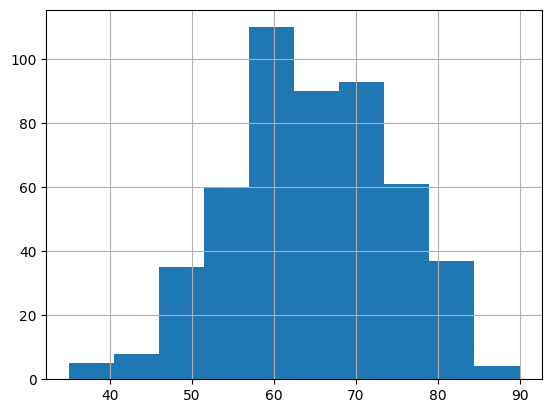

In [11]:
df['AGE '].hist()

<Axes: >

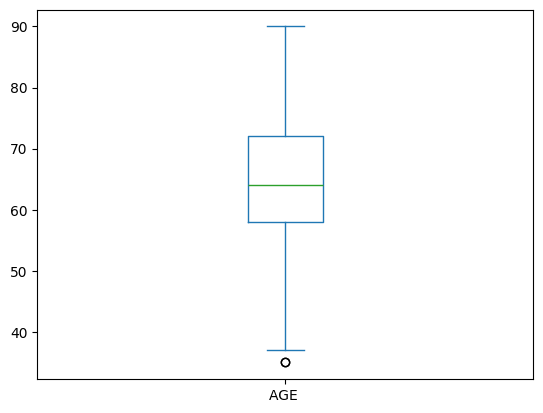

In [12]:
df['AGE '].plot.box()

array([<Axes: title={'center': 'F'}>, <Axes: title={'center': 'M'}>],
      dtype=object)

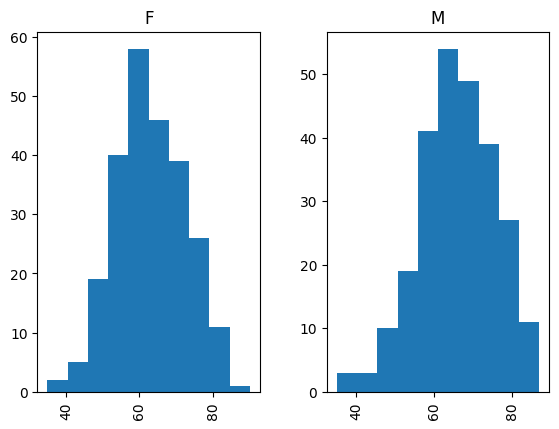

In [16]:
df.hist(column='AGE ', by='SEX')

,0
AGE,"Axes(0.125,0.11;0.775x0.77)"


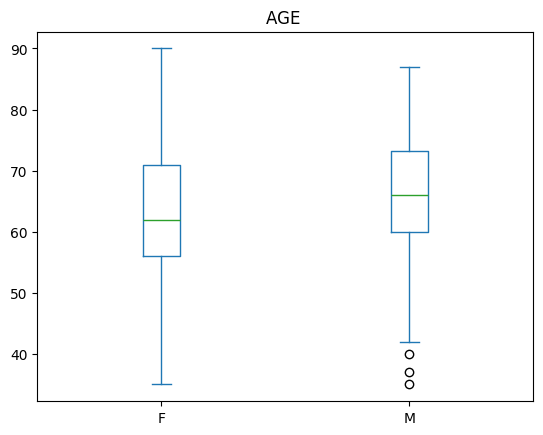

In [17]:
df.plot.box(column='AGE ', by='SEX')

<Axes: xlabel='AGE ', ylabel='SEX'>

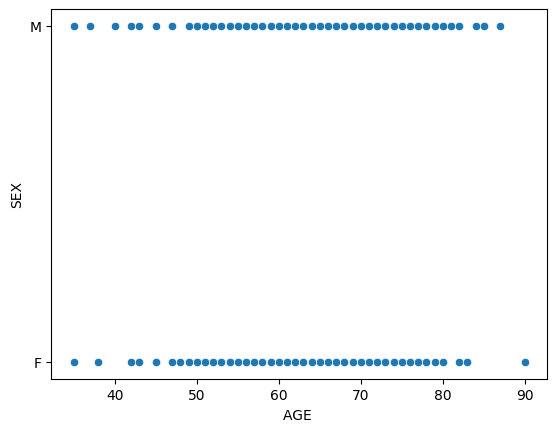

In [18]:
import seaborn as sns
sns.scatterplot(x='AGE ', y='SEX', data=df)

In [19]:
from scipy.stats import chi2_contingency

# Create age groups
bins = [30, 40, 50, 60, 70, 80, 90]
labels = ['30-39', '40-49', '50-59', '60-69', '70-79', '80-90']
df['AGE_group'] = pd.cut(df['AGE '], bins=bins, labels=labels, right=False)

# Create a contingency table
contingency_table = pd.crosstab(df['SEX'], df['AGE_group'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies table:")
print(expected)

Chi-square statistic: 14.490428848545879
p-value: 0.012776687930611525
Degrees of freedom: 5
Expected frequencies table:
[[ 1.96015936  8.33067729 65.66533865 89.67729084 66.15537849 14.21115538]
 [ 2.03984064  8.66932271 68.33466135 93.32270916 68.84462151 14.78884462]]


In [21]:
from scipy.stats import ttest_ind

# Separate the age data for males and females
male_age = df[df['SEX'] == 'M']['AGE ']
female_age = df[df['SEX'] == 'F']['AGE ']

# Perform the independent t-test
t_statistic, p_value = ttest_ind(male_age, female_age)

print("T-test for AGE by SEX:")
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

T-test for AGE by SEX:
T-statistic: 3.456382673890146
P-value: 0.0005940226192169183


In [20]:
from scipy.stats import ttest_ind

# Separate the data for males and females
male_df = df[df['SEX'] == 'M']
female_df = df[df['SEX'] == 'F']

# Columns to perform t-test on
columns_to_test = ['KH', 'KV', 'AL', 'ACD', 'LT']

# Perform t-test for each column
for col in columns_to_test:
    t_stat, p_val = ttest_ind(male_df[col], female_df[col])
    print(f"T-test for {col}:")
    print(f"T-statistic: {t_stat}")
    print(f"P-value: {p_val}\n")

T-test for KH:
T-statistic: -2.2047402952403874
P-value: 0.02792602047607459

T-test for KV:
T-statistic: -2.3792211004791133
P-value: 0.017722814858840072

T-test for AL:
T-statistic: 1.73829551595108
P-value: 0.08277312683314841

T-test for ACD:
T-statistic: 1.806803122420344
P-value: 0.07139280980742012

T-test for LT:
T-statistic: -0.9812279185020604
P-value: 0.32695395206758404



In [22]:
df['SEX_numeric'] = df['SEX'].map({'M': 1, 'F': 0})
df.head()

,AGE,SEX,KH,KV,AXIS,AL,ACD,LT,AGE_group,SEX_numeric
0,65,M,45.75,43.25,15.0,21.90,2.35,3.45,60-69,1
1,65,M,44.25,44.75,25.0,22.97,3.56,3.45,60-69,1
2,79,M,42.25,43.00,30.0,23.76,2.44,4.56,70-79,1
3,69,M,43.25,43.75,90.0,22.77,2.98,3.78,60-69,1
4,72,M,44.00,46.75,95.0,22.99,3.45,3.78,70-79,1


In [23]:
df.columns

Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT', 'AGE_group',
       'SEX_numeric'],
      dtype='object')

In [27]:
corr = df[['AGE ','KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT',
       'SEX_numeric']].corr()
corr

,AGE,KH,KV,AXIS,AL,ACD,LT,SEX_numeric
AGE,1.000000,-0.359789,-0.337968,-0.082054,0.375333,0.138615,-0.196134,0.152611
KH,-0.359789,1.000000,0.925555,0.037769,-0.686417,-0.399329,0.380340,-0.098026
KV,-0.337968,0.925555,1.000000,0.057635,-0.691322,-0.408852,0.383358,-0.105700
AXIS,-0.082054,0.037769,0.057635,1.000000,-0.089184,-0.093266,0.031591,0.023541
AL,0.375333,-0.686417,-0.691322,-0.089184,1.000000,0.461342,-0.436640,0.077428
ACD,0.138615,-0.399329,-0.408852,-0.093266,0.461342,1.000000,-0.479859,0.080460
LT,-0.196134,0.380340,0.383358,0.031591,-0.436640,-0.479859,1.000000,-0.043796
SEX_numeric,0.152611,-0.098026,-0.105700,0.023541,0.077428,0.080460,-0.043796,1.000000


<Axes: >

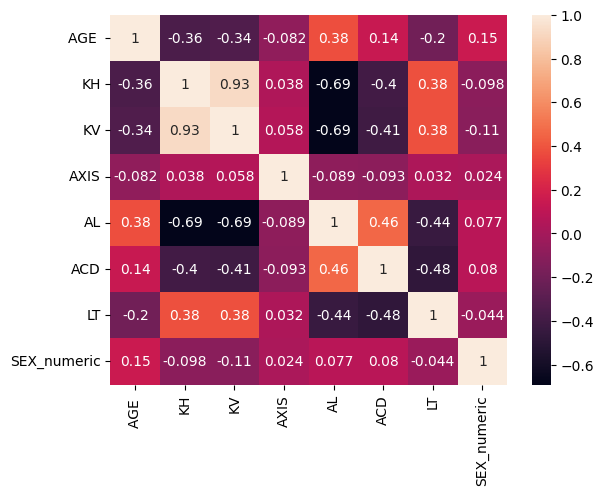

In [31]:
sns.heatmap(corr, annot=True)

In [35]:
df[['KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT']].describe()


,KH,KV,AXIS,AL,ACD,LT
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,44.115109,44.729225,87.368032,22.995288,3.261889,3.830358
std,1.870773,1.850323,51.707667,1.024446,0.461919,0.561864
min,38.000000,39.000000,5.000000,20.000000,2.110000,2.350000
25%,43.000000,43.500000,45.000000,22.295000,2.950000,3.450000
50%,44.250000,44.750000,85.000000,22.950000,3.250000,3.850000
75%,45.500000,46.000000,130.000000,23.610000,3.560000,4.210000
max,52.000000,52.500000,185.000000,25.600000,4.890000,5.450000
